In [1]:
# ============================================================================
# SIMPLE COMPARISON: Weighted PCA vs Plain PCA on 80 Genes
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path

print("=== WEIGHTED vs PLAIN PCA COMPARISON ===")

# Load the 80 DE genes directly from DE results
de_results = pd.read_csv("../results/80_DESeq2_significant_genes_lfc_fdr.csv")
print(f"Loaded DE results: {de_results.shape}")

# Create weights from DE results: |log2FC| * -log10(padj)
de_weights = (de_results['log2FoldChange'].abs() * (-np.log10(np.clip(de_results['padj'], 1e-300, 1)))).values
# Normalize weights to [0,1] range
de_weights = (de_weights - de_weights.min()) / (de_weights.max() - de_weights.min() + 1e-12) + 1e-6

print(f"Created weights from DE results:")
print(f"  Min weight: {de_weights.min():.3f}")
print(f"  Max weight: {de_weights.max():.3f}")
print(f"  Mean weight: {de_weights.mean():.3f}")

# Load expression data
expr_data = pd.read_csv("../results/GSE95640_DeSEQ2_normalized_counts.csv", index_col=0)
print(f"Loaded expression data: {expr_data.shape}")

# Load gene annotation to map IDs to symbols
gene_annot = pd.read_csv("../data/Human.GRCh38.p13.annot.tsv", sep='\t', low_memory=False)
gene_mapping = gene_annot[gene_annot['Symbol'].isin(de_results['Symbol'])]
id_to_symbol = dict(zip(gene_mapping['GeneID'].astype(str), gene_mapping['Symbol']))

# Filter expression data to the 80 genes
expr_filtered = expr_data[expr_data.index.astype(str).isin(id_to_symbol.keys())]
expr_filtered.index = expr_filtered.index.astype(str).map(id_to_symbol)

# Align genes between expression and DE results
symbol_to_weight = dict(zip(de_results['Symbol'], de_weights))
common_genes = list(set(expr_filtered.index) & set(de_results['Symbol']))
X = expr_filtered.loc[common_genes].T.values  # samples x genes
gene_weights = np.array([symbol_to_weight[gene] for gene in common_genes])

print(f"Using {len(common_genes)} common genes")
print(f"Data matrix: {X.shape[0]} samples × {X.shape[1]} genes")

=== WEIGHTED vs PLAIN PCA COMPARISON ===
Loaded DE results: (80, 24)
Created weights from DE results:
  Min weight: 0.000
  Max weight: 1.000
  Mean weight: 0.168
Loaded expression data: (39376, 382)
Using 80 common genes
Data matrix: 382 samples × 80 genes
Loaded expression data: (39376, 382)
Using 80 common genes
Data matrix: 382 samples × 80 genes


In [8]:
# ============================================================================
# PERFORM BOTH PCA ANALYSES
# ============================================================================

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check and clean gene weights
print(f"Gene weights info:")
print(f"  Shape: {gene_weights.shape}")
print(f"  NaN values: {np.isnan(gene_weights).sum()}")
print(f"  Range: {gene_weights.min():.3f} to {gene_weights.max():.3f}")

# Clean weights: replace NaN with mean, ensure positive values
gene_weights_clean = gene_weights.copy()
if np.isnan(gene_weights_clean).any():
    gene_weights_clean[np.isnan(gene_weights_clean)] = np.nanmean(gene_weights_clean)
    print("  Fixed NaN values with mean")

# Ensure all weights are positive
if (gene_weights_clean <= 0).any():
    gene_weights_clean = gene_weights_clean - gene_weights_clean.min() + 1e-6
    print("  Made all weights positive")

print("\n=== ANALYSIS 1: PLAIN PCA (Standard) ===")
# 1. Plain PCA on 80 genes
pca_plain = PCA(n_components=50, random_state=42)
scores_plain = pca_plain.fit_transform(X_scaled)
var_plain = pca_plain.explained_variance_ratio_
cum_var_plain = np.cumsum(var_plain)

print(f"Plain PCA completed with {len(var_plain)} components")
print(f"First 5 components: {var_plain[:5] * 100}")

print("\n=== ANALYSIS 2: WEIGHTED PCA (Pathway-weighted) ===")
# 2. Weighted PCA using cleaned pathway weights
X_weighted = X_scaled * np.sqrt(gene_weights_clean)[None, :]  # weight by sqrt of pathway weights
pca_weighted = PCA(n_components=50, random_state=42)
scores_weighted = pca_weighted.fit_transform(X_weighted)
var_weighted = pca_weighted.explained_variance_ratio_
cum_var_weighted = np.cumsum(var_weighted)

print(f"Weighted PCA completed with {len(var_weighted)} components")
print(f"First 5 components: {var_weighted[:5] * 100}")

print("\n=== VARIANCE COMPARISON ===")
print("Components  | Plain PCA | Weighted PCA | Difference")
print("-" * 50)
for i in [1, 5, 10, 15, 20]:
    if i <= len(cum_var_plain) and i <= len(cum_var_weighted):
        plain_cum = cum_var_plain[i-1] * 100
        weighted_cum = cum_var_weighted[i-1] * 100
        diff = weighted_cum - plain_cum
        print(f"{i:2d}          | {plain_cum:8.1f}% | {weighted_cum:11.1f}% | {diff:+6.1f}%")

Gene weights info:
  Shape: (80,)
  NaN values: 0
  Range: 0.000 to 1.000

=== ANALYSIS 1: PLAIN PCA (Standard) ===
Plain PCA completed with 50 components
First 5 components: [26.2055704   6.69804767  5.27781927  4.57631788  4.2834543 ]

=== ANALYSIS 2: WEIGHTED PCA (Pathway-weighted) ===
Weighted PCA completed with 50 components
First 5 components: [41.28543686 10.28318712  5.20780556  4.15257078  2.99085776]

=== VARIANCE COMPARISON ===
Components  | Plain PCA | Weighted PCA | Difference
--------------------------------------------------
 1          |     26.2% |        41.3% |  +15.1%
 5          |     47.0% |        63.9% |  +16.9%
10          |     59.1% |        75.5% |  +16.4%
15          |     67.5% |        82.6% |  +15.1%
20          |     74.1% |        87.4% |  +13.3%


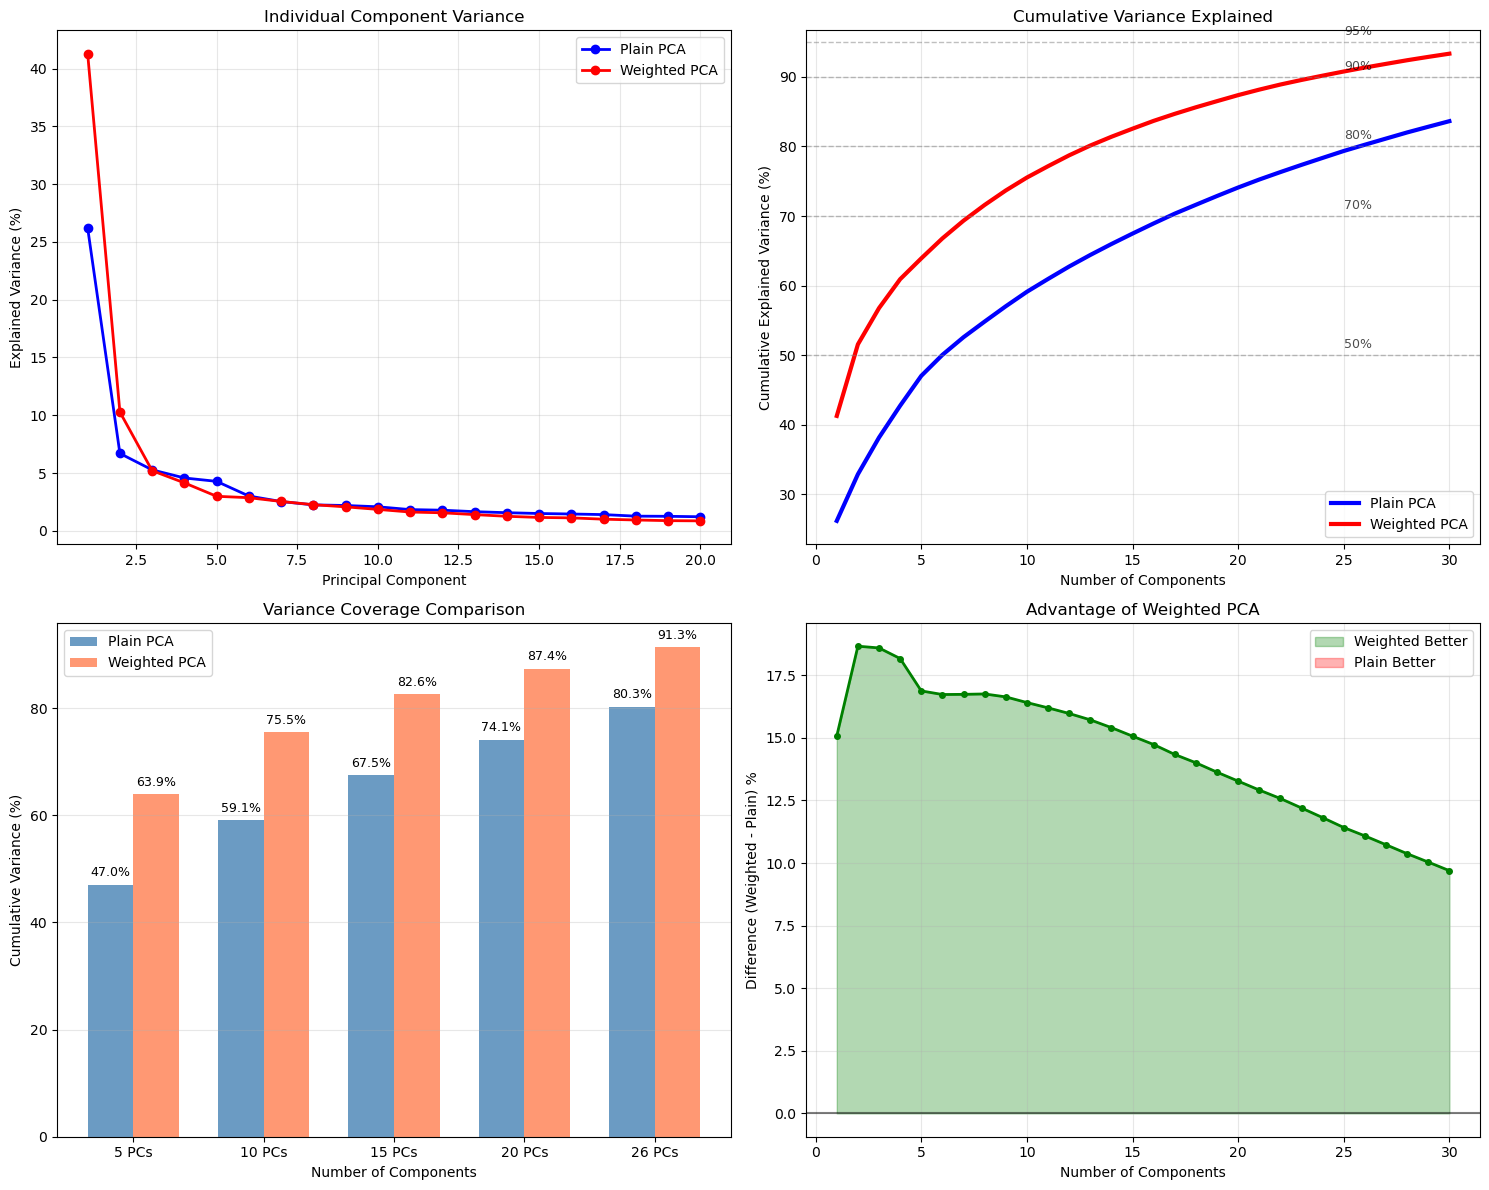


=== SUMMARY INSIGHTS ===
🏆 WINNER at 10 components:
   Weighted PCA: 75.5% vs Plain PCA: 59.1%
   Advantage: +16.4%

🏆 WINNER at 26 components:
   Weighted PCA: 91.3% vs Plain PCA: 80.3%
   Advantage: +11.1%


In [15]:
# ============================================================================
# VISUALIZATION COMPARISON
# ============================================================================

# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Individual component variance
ax = axes[0, 0]
components = range(1, min(21, len(var_plain) + 1))
ax.plot(components, var_plain[:20] * 100, 'bo-', label='Plain PCA', linewidth=2, markersize=6)
ax.plot(components, var_weighted[:20] * 100, 'ro-', label='Weighted PCA', linewidth=2, markersize=6)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Individual Component Variance')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Cumulative variance
ax = axes[0, 1]
components = range(1, min(31, len(cum_var_plain) + 1))
ax.plot(components, cum_var_plain[:30] * 100, 'b-', label='Plain PCA', linewidth=3)
ax.plot(components, cum_var_weighted[:30] * 100, 'r-', label='Weighted PCA', linewidth=3)

# Add milestone lines
for milestone in [50, 70, 80, 90, 95]:
    ax.axhline(y=milestone, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(25, milestone + 1, f'{milestone}%', fontsize=9, alpha=0.7)

ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Variance Explained')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Bar comparison for key milestones
ax = axes[1, 0]
milestones = [5, 10, 15, 20, 26]
plain_values = [cum_var_plain[i-1] * 100 for i in milestones if i <= len(cum_var_plain)]
weighted_values = [cum_var_weighted[i-1] * 100 for i in milestones if i <= len(cum_var_weighted)]
milestone_labels = [f'{i} PCs' for i in milestones[:len(plain_values)]]

x = np.arange(len(milestone_labels))
width = 0.35

bars1 = ax.bar(x - width/2, plain_values, width, label='Plain PCA', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, weighted_values, width, label='Weighted PCA', alpha=0.8, color='coral')

ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Variance (%)')
ax.set_title('Variance Coverage Comparison')
ax.set_xticks(x)
ax.set_xticklabels(milestone_labels)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Plot 4: Difference plot
ax = axes[1, 1]
components = range(1, min(31, len(cum_var_plain) + 1))
difference = (cum_var_weighted[:30] - cum_var_plain[:30]) * 100
ax.plot(components, difference, 'go-', linewidth=2, markersize=4)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Difference (Weighted - Plain) %')
ax.set_title('Advantage of Weighted PCA')
ax.grid(True, alpha=0.3)

# Highlight positive vs negative differences
positive_mask = difference > 0
ax.fill_between(components, 0, difference, where=positive_mask, 
                color='green', alpha=0.3, label='Weighted Better')
ax.fill_between(components, 0, difference, where=~positive_mask, 
                color='red', alpha=0.3, label='Plain Better')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n=== SUMMARY INSIGHTS ===")
print(f"🏆 WINNER at 10 components:")
if cum_var_weighted[9] > cum_var_plain[9]:
    print(f"   Weighted PCA: {cum_var_weighted[9]*100:.1f}% vs Plain PCA: {cum_var_plain[9]*100:.1f}%")
    print(f"   Advantage: +{(cum_var_weighted[9] - cum_var_plain[9])*100:.1f}%")
else:
    print(f"   Plain PCA: {cum_var_plain[9]*100:.1f}% vs Weighted PCA: {cum_var_weighted[9]*100:.1f}%")
    print(f"   Advantage: +{(cum_var_plain[9] - cum_var_weighted[9])*100:.1f}%")

print(f"\n🏆 WINNER at 26 components:")
if cum_var_weighted[25] > cum_var_plain[25]:
    print(f"   Weighted PCA: {cum_var_weighted[25]*100:.1f}% vs Plain PCA: {cum_var_plain[25]*100:.1f}%")
    print(f"   Advantage: +{(cum_var_weighted[25] - cum_var_plain[25])*100:.1f}%")
else:
    print(f"   Plain PCA: {cum_var_plain[25]*100:.1f}% vs Weighted PCA: {cum_var_weighted[25]*100:.1f}%")
    print(f"   Advantage: +{(cum_var_plain[25] - cum_var_weighted[25])*100:.1f}%")